## 1. Configuration and Setup



In [1]:
from pathlib import Path

import librosa
import librosa.display as librosa_display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objs as go
import plotly.offline as py
import seaborn as sns
from IPython.display import display
from scipy import signal
from scipy.fftpack import fft
from scipy.io import wavfile

py.init_notebook_mode(connected=True)
sns.set_theme(style="whitegrid")
sns.set_palette("Set2")


def locate_train_root() -> Path:
    rel = Path("data/kaggle_speech_commands/tensorflow-speech-recognition-challenge/train")
    candidates = [
        Path.cwd() / rel,
        Path.cwd().parent / rel,
        Path.cwd().parent.parent / rel,
        Path("/Users/pawelflorek/PW/DS/sem1/DL/speech-recognition") / rel,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    raise FileNotFoundError(
        "Nie znaleziono katalogu train. Sprawdź ścieżkę do data/kaggle_speech_commands/.../train."
    )


TRAIN_ROOT = locate_train_root()
AUDIO_DIR = TRAIN_ROOT / "audio"
SPLIT_DIR = TRAIN_ROOT / "split_lists"


def read_split_list(name: str) -> list[str]:
    list_path = SPLIT_DIR / name
    if not list_path.exists():
        available = sorted(p.name for p in SPLIT_DIR.glob("*_list.txt"))
        raise FileNotFoundError(f"Brak pliku {list_path}. Dostępne listy: {available}")

    lines = list_path.read_text(encoding="utf-8").splitlines()
    cleaned = []
    for line in lines:
        rel = line.strip()
        if not rel:
            continue
        if rel.startswith("audio/"):
            rel = rel[len("audio/") :]
        cleaned.append(rel)
    return cleaned


PREFIX = ""
train_list = read_split_list(f"{PREFIX}training_list.txt")
val_list = read_split_list(f"{PREFIX}validation_list.txt")
test_list = read_split_list(f"{PREFIX}testing_list.txt")


def make_split_df(split_name: str, rel_paths: list[str]) -> pd.DataFrame:
    df = pd.DataFrame({"split": split_name, "rel_path": rel_paths})
    df["label"] = df["rel_path"].str.split("/").str[0]
    df["path"] = df["rel_path"].apply(lambda p: AUDIO_DIR / p)
    return df


df_train = make_split_df("train", train_list)
df_val = make_split_df("validation", val_list)
df_test = make_split_df("test", test_list)
df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
dirs = sorted(df_train["label"].unique())

split_sizes = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "n_files": [len(df_train), len(df_val), len(df_test)],
    }
)
display(split_sizes)
print(f"TRAIN_ROOT={TRAIN_ROOT}")
print(f"AUDIO_DIR={AUDIO_DIR}")
print(f"SPLIT_DIR={SPLIT_DIR}")

,split,n_files
0,train,18946
1,validation,2368
2,test,2368


TRAIN_ROOT=/Users/pawelflorek/PW/DS/sem1/DL/speech-recognition/data/kaggle_speech_commands/tensorflow-speech-recognition-challenge/train
AUDIO_DIR=/Users/pawelflorek/PW/DS/sem1/DL/speech-recognition/data/kaggle_speech_commands/tensorflow-speech-recognition-challenge/train/audio
SPLIT_DIR=/Users/pawelflorek/PW/DS/sem1/DL/speech-recognition/data/kaggle_speech_commands/tensorflow-speech-recognition-challenge/train/split_lists


## 2. Support functions

In [2]:
def log_specgram(audio, sample_rate, window_size=20, step_size=10, eps=1e-10):
    nperseg = round(window_size * sample_rate / 1e3)
    noverlap = round(step_size * sample_rate / 1e3)
    freqs, times, spec = signal.spectrogram(
        audio,
        fs=sample_rate,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        detrend=False,
    )
    return freqs, times, np.log(spec.T.astype(np.float32) + eps)


def custom_fft(y, fs):
    t = 1.0 / fs
    n = y.shape[0]
    yf = fft(y)
    xf = np.linspace(0.0, 1.0 / (2.0 * t), n // 2)
    vals = 2.0 / n * np.abs(yf[0 : n // 2])
    return xf, vals

## 3. Raw waveforms and spectrograms

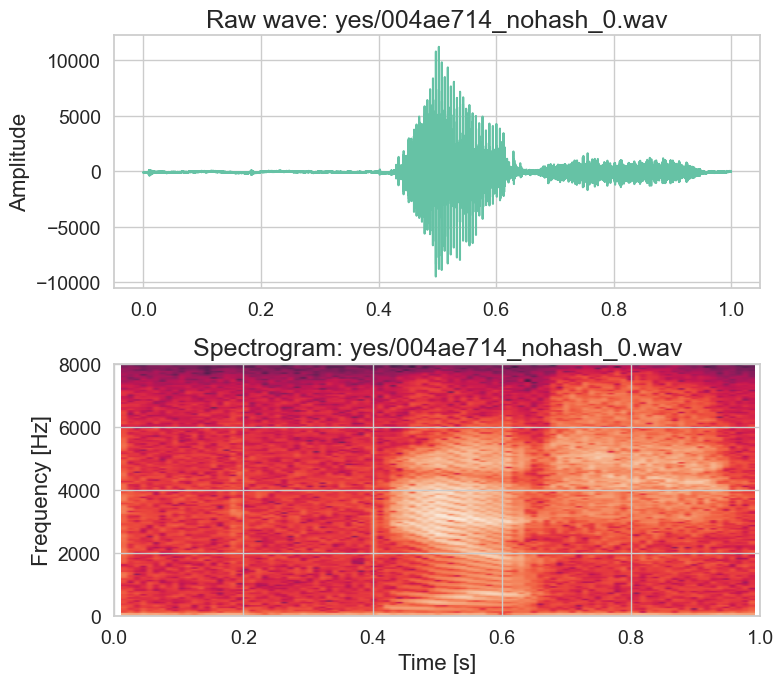

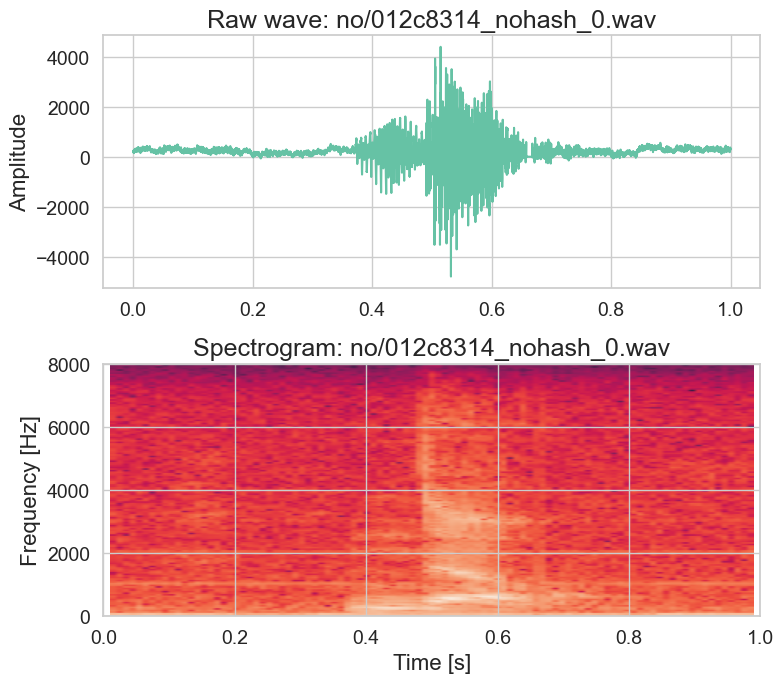

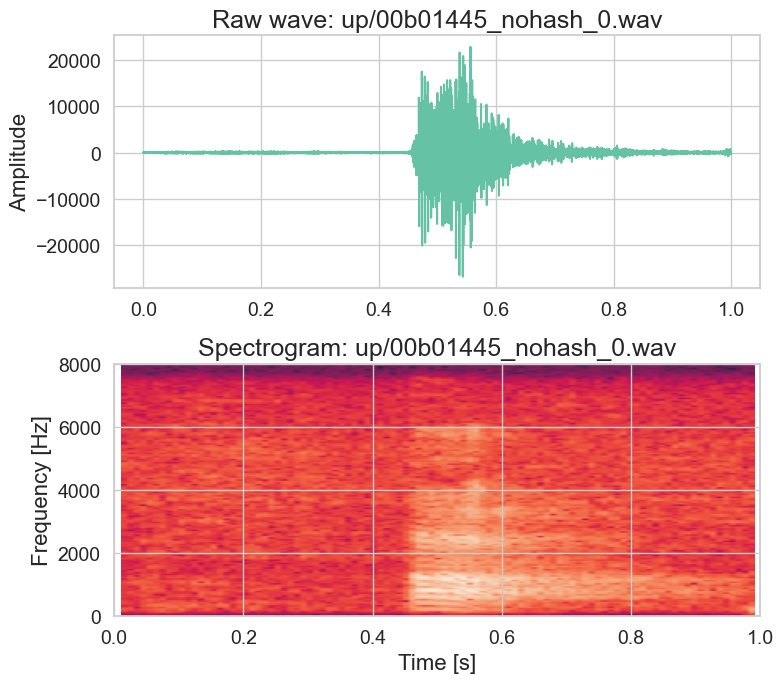

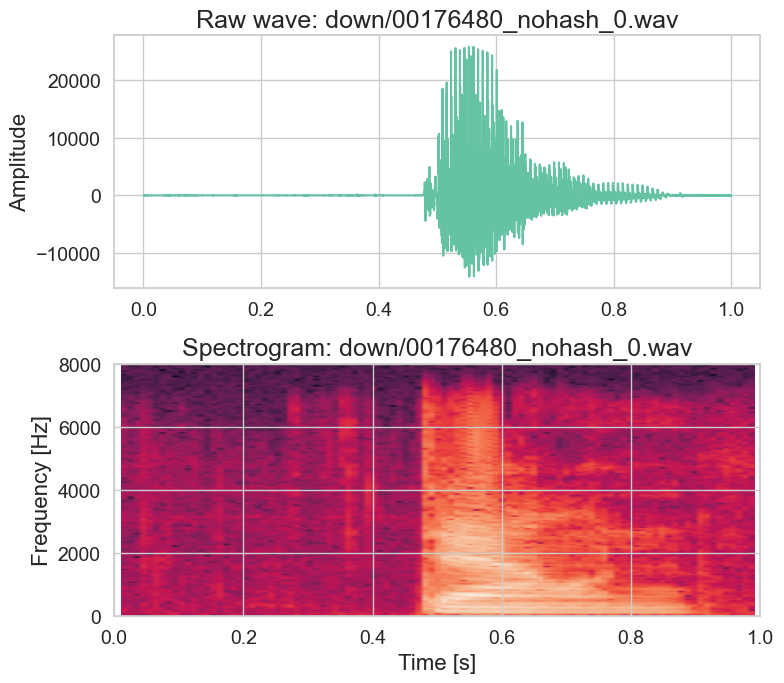

In [ ]:
yes_candidates = df_train[df_train["label"] == "yes"]["rel_path"].tolist()
filename = yes_candidates[0] if yes_candidates else train_list[0]
sample_rate, samples = wavfile.read(AUDIO_DIR / filename)
freqs, times, spectrogram = log_specgram(samples, sample_rate)

fig = plt.figure(figsize=(8, 7))
ax1 = fig.add_subplot(211)
ax1.set_title(f"Raw wave: {filename}", fontsize=18)
ax1.set_ylabel("Amplitude", fontsize=16)
ax1.plot(np.linspace(0, len(samples) / sample_rate, len(samples)), samples)
ax1.tick_params(axis="both", which="major", labelsize=14)

ax2 = fig.add_subplot(212)
ax2.imshow(
    spectrogram.T,
    aspect="auto",
    origin="lower",
    extent=[times.min(), times.max(), freqs.min(), freqs.max()],
)
ax2.set_yticks(np.arange(0, freqs.max() + 1, 2000))
ax2.set_xticks(np.round(np.linspace(times.min(), times.max(), 6), 1))
ax2.set_title(f"Spectrogram: {filename}", fontsize=18)
ax2.set_ylabel("Frequency [Hz]", fontsize=16)
ax2.set_xlabel("Time [s]", fontsize=16)
ax2.tick_params(axis="both", which="major", labelsize=14)
plt.tight_layout()
plt.savefig("./plots/spectrogram_example_yes.png", dpi=500)

classes_to_plot = ["no", "up", "down"]

for cls in classes_to_plot:
    candidates = df_train[df_train["label"] == cls]["rel_path"].tolist()
    filename = (
        candidates[0]
        if candidates
        else next((p for p in train_list if p.startswith(f"{cls}/")), train_list[0])
    )

    sample_rate, samples = wavfile.read(AUDIO_DIR / filename)
    freqs, times, spectrogram = log_specgram(samples, sample_rate)

    fig = plt.figure(figsize=(8, 7))
    ax1 = fig.add_subplot(211)
    ax1.set_title(f"Raw wave: {filename}", fontsize=18)
    ax1.set_ylabel("Amplitude", fontsize=16)
    ax1.plot(np.linspace(0, len(samples) / sample_rate, len(samples)), samples)
    ax1.tick_params(axis="both", which="major", labelsize=14)

    ax2 = fig.add_subplot(212)
    ax2.imshow(
        spectrogram.T,
        aspect="auto",
        origin="lower",
        extent=[times.min(), times.max(), freqs.min(), freqs.max()],
    )
    ax2.set_yticks(np.arange(0, freqs.max() + 1, 2000))
    ax2.set_xticks(np.round(np.linspace(times.min(), times.max(), 6), 1))
    ax2.set_title(f"Spectrogram: {filename}", fontsize=18)
    ax2.set_ylabel("Frequency [Hz]", fontsize=16)
    ax2.set_xlabel("Time [s]", fontsize=16)
    ax2.tick_params(axis="both", which="major", labelsize=14)
    plt.tight_layout()
    plt.savefig(f"./plots/spectrogram_example_{cls}.png", dpi=500)
    plt.show()

## 4. Mel-spectrograms i MFCC

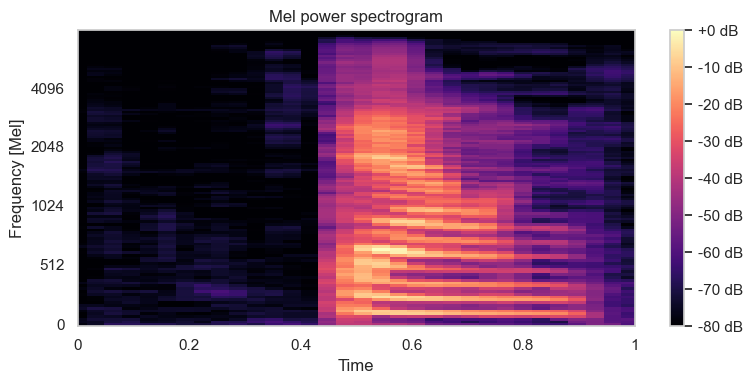

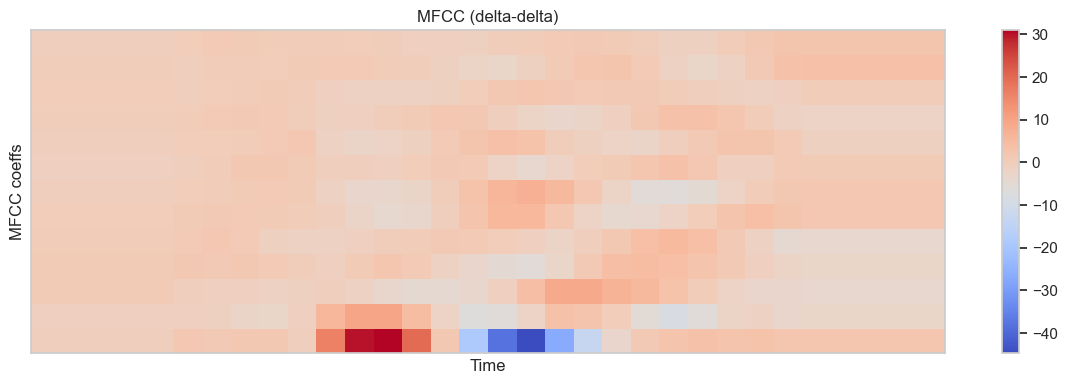

In [4]:
s_mel = librosa.feature.melspectrogram(y=samples.astype(float), sr=sample_rate, n_mels=128)
log_s_mel = librosa.power_to_db(s_mel, ref=np.max)

plt.figure(figsize=(8, 4))
librosa_display.specshow(log_s_mel, sr=sample_rate, x_axis="time", y_axis="mel")
plt.title("Mel power spectrogram")
plt.colorbar(format="%+02.0f dB")
plt.xlim(0, 1)
plt.xticks(np.round(np.linspace(0, times.max(), 6), 1))
plt.ylabel("Frequency [Mel]")
plt.tight_layout()
# plt.savefig("./plots/mel_power_spectrogram_example.png", dpi=500)
plt.show()

mfcc = librosa.feature.mfcc(S=log_s_mel, n_mfcc=13)
delta2_mfcc = librosa.feature.delta(mfcc, order=2)

plt.figure(figsize=(12, 4))
librosa_display.specshow(delta2_mfcc)
plt.ylabel("MFCC coeffs")
plt.xlabel("Time")
plt.title("MFCC (delta-delta)")
plt.colorbar()
plt.tight_layout()
# plt.savefig("./plots/mfcc_example.png", dpi=500)
plt.show()

## 5. Spektrogram 3D


In [5]:
data = [go.Surface(z=spectrogram.T)]
layout = go.Layout(
    title="Spectrogram in 3D",
    scene={
        "yaxis": {"title": "Frequency"},
        "xaxis": {"title": "Time"},
        "zaxis": {"title": "Log amplitude"},
    },
)
fig = go.Figure(data=data, layout=layout)
py.iplot(fig)

## 7. Resampling and FFT comparison

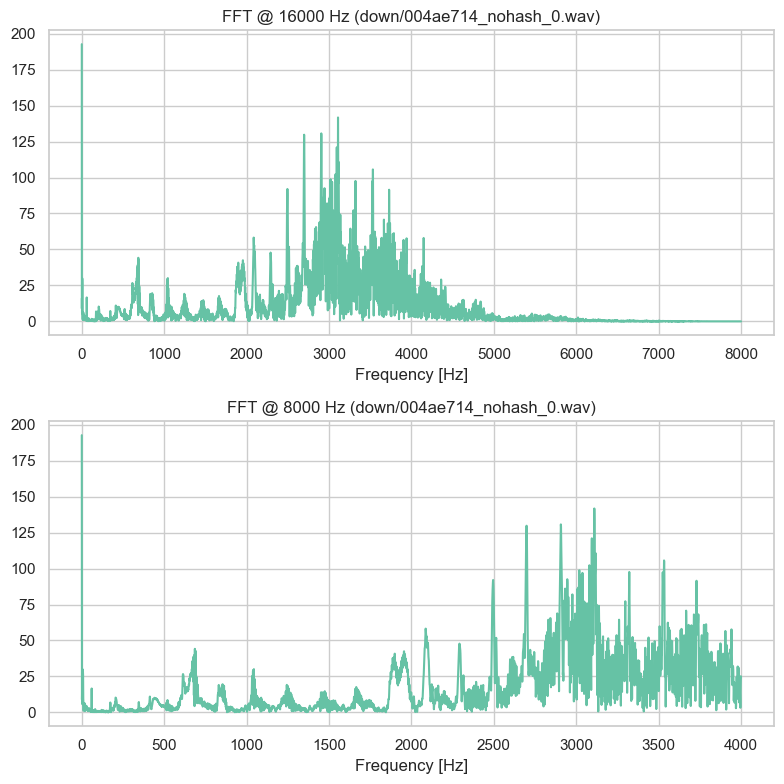

In [6]:
happy_candidates = df_train[df_train["label"] == "happy"]["rel_path"].tolist()
filename_resample = (
    happy_candidates[0] if happy_candidates else train_list[min(1, len(train_list) - 1)]
)
new_sample_rate = 8000

sample_rate_h, samples_h = wavfile.read(AUDIO_DIR / filename_resample)
resampled = signal.resample(samples_h, int(new_sample_rate / sample_rate_h * samples_h.shape[0]))

xf_orig, vals_orig = custom_fft(samples_h, sample_rate_h)
xf_res, vals_res = custom_fft(resampled, new_sample_rate)

fig, axes = plt.subplots(2, 1, figsize=(8, 8))
axes[0].plot(xf_orig, vals_orig)
axes[0].set_title(f"FFT @ {sample_rate_h} Hz ({filename_resample})")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].grid(True)

axes[1].plot(xf_res, vals_res)
axes[1].set_title(f"FFT @ {new_sample_rate} Hz ({filename_resample})")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 8. Histrograms



split,label,test,train,validation
0,down,261,1867,231
1,go,242,1899,231
2,left,210,1894,249
3,no,250,1908,217
4,off,228,1890,239
5,on,255,1891,221
6,right,231,1907,229
7,stop,245,1878,257
8,up,231,1908,236
9,yes,215,1904,258


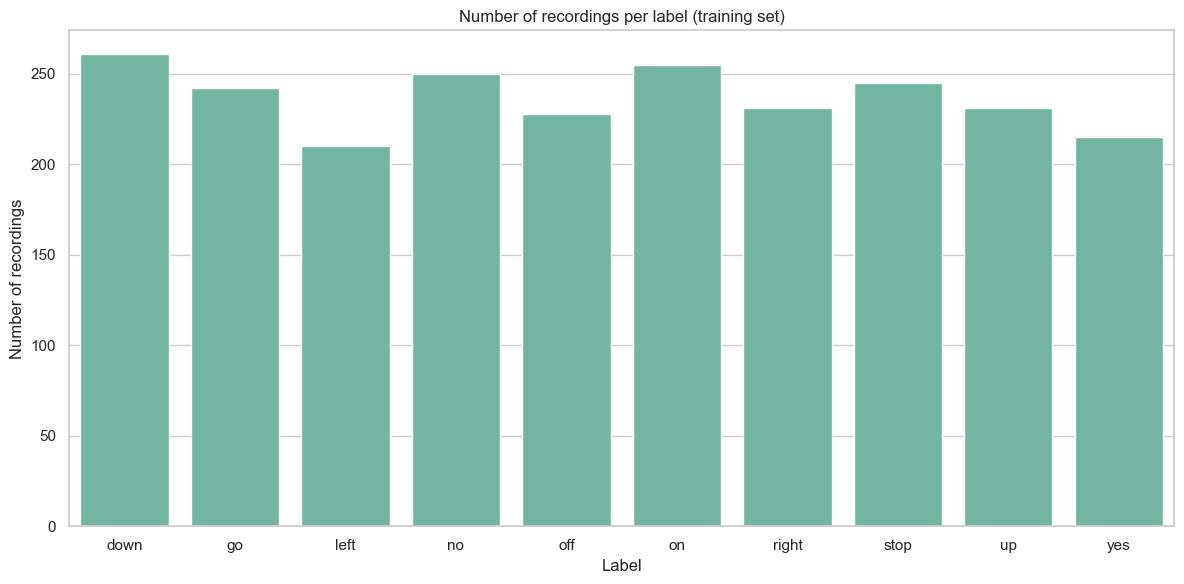

In [7]:
records_split_df = (
    df_all.groupby(["split", "label"])
    .size()
    .reset_index(name="num_recordings")
    .sort_values(["split", "num_recordings"], ascending=[True, False])
)
# display(records_split_df.reset_index(drop=True))

records_split_df = (
    records_split_df.pivot(index="label", columns="split", values="num_recordings")
    .fillna(0)
    .astype(int)
    .reset_index()
)

display(records_split_df.reset_index(drop=True))

plt.figure(figsize=(12, 6))
sns.barplot(data=records_split_df, x="label", y="test")
# plt.xticks(rotation=45)
plt.title("Number of recordings per label (training set)")
plt.xlabel("Label")
plt.ylabel("Number of recordings")
plt.tight_layout()
# plt.savefig("./plots/recordings_per_label_train.png", dpi=500)
plt.show()

## 9. Differences between speakers

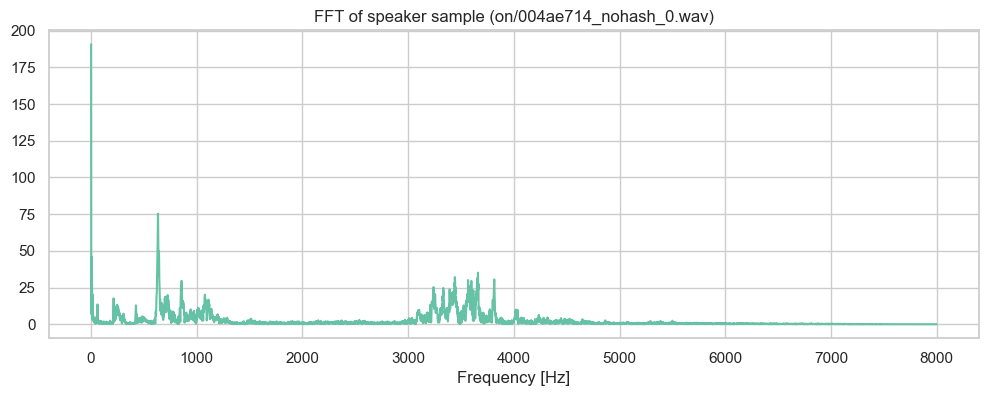

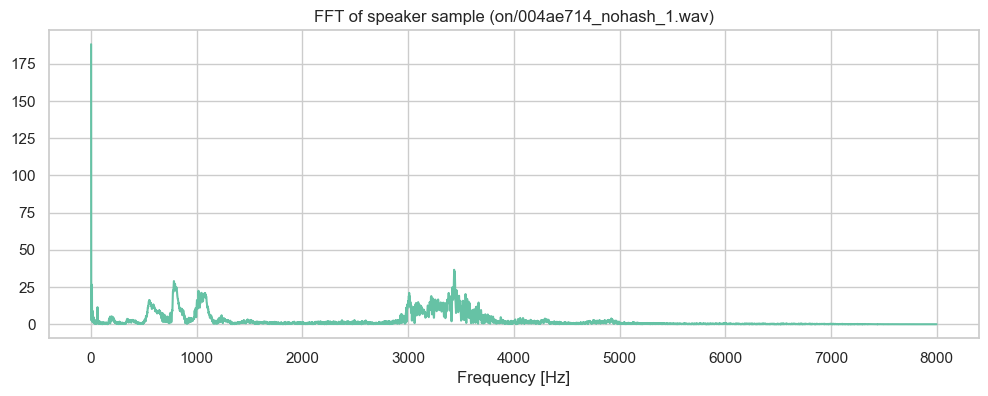

In [8]:
on_candidates = df_train[df_train["label"] == "on"]["rel_path"].head(2).tolist()
if len(on_candidates) < 2:
    on_candidates = train_list[:2]

speaker_files = on_candidates

for speaker_file in speaker_files:
    sr_spk, samples_spk = wavfile.read(AUDIO_DIR / speaker_file)
    xf_spk, vals_spk = custom_fft(samples_spk, sr_spk)
    plt.figure(figsize=(12, 4))
    plt.title(f"FFT of speaker sample ({speaker_file})")
    plt.plot(xf_spk, vals_spk)
    plt.xlabel("Frequency [Hz]")
    plt.grid(True)
    plt.show()

## 11. Recording lengths


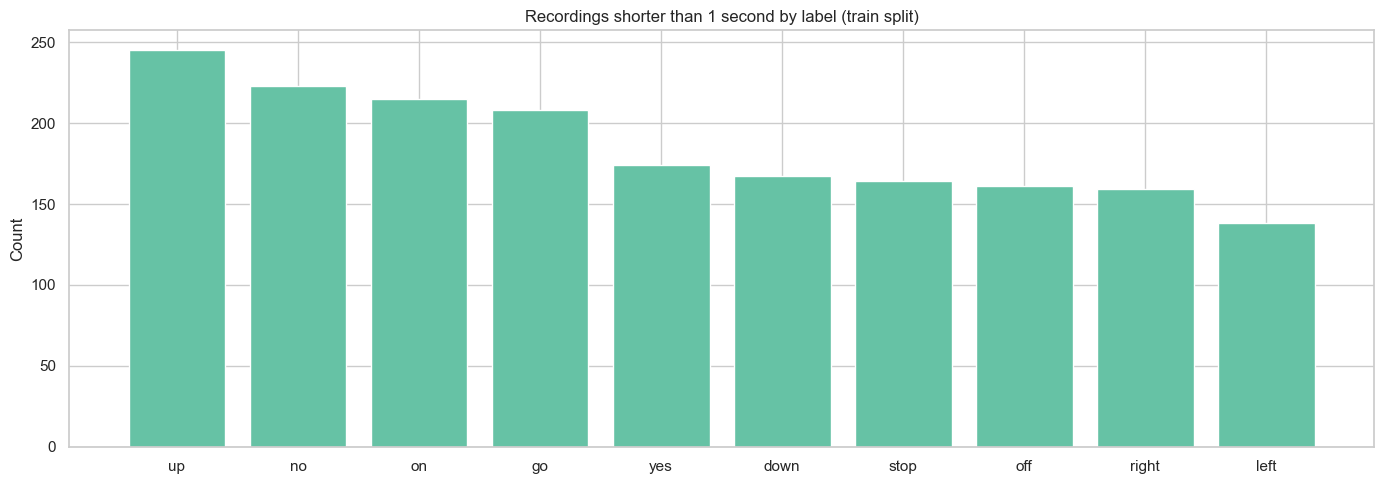

In [9]:
length_rows = []
for split_name, df_split in [
    ("train", df_train),
    ("validation", df_val),
    ("test", df_test),
]:
    for direct in sorted(df_split["label"].unique()):
        split_label_df = df_split[df_split["label"] == direct]
        durations = []
        shorter_count = 0
        for rel_path in split_label_df["rel_path"]:
            sr_len, samples_len = wavfile.read(AUDIO_DIR / rel_path)
            durations.append(samples_len.shape[0] / sr_len)
            if samples_len.shape[0] < sr_len:
                shorter_count += 1

        length_rows.append(
            {
                "split": split_name,
                "label": direct,
                "n_files": len(split_label_df),
                "n_shorter_than_1s": shorter_count,
                "pct_shorter_than_1s": 100.0 * shorter_count / max(len(split_label_df), 1),
                "mean_duration_s": float(np.mean(durations)) if durations else np.nan,
            }
        )

length_df = pd.DataFrame(length_rows).sort_values(
    ["split", "n_shorter_than_1s"], ascending=[True, False]
)
# display(length_df.reset_index(drop=True))

length_train_df = length_df[length_df["split"] == "train"]
plt.figure(figsize=(14, 5))
plt.bar(length_train_df["label"], length_train_df["n_shorter_than_1s"])
# plt.xticks(rotation=90)
plt.title("Recordings shorter than 1 second by label (train split)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 12. Mean FFT and mean spectrograms


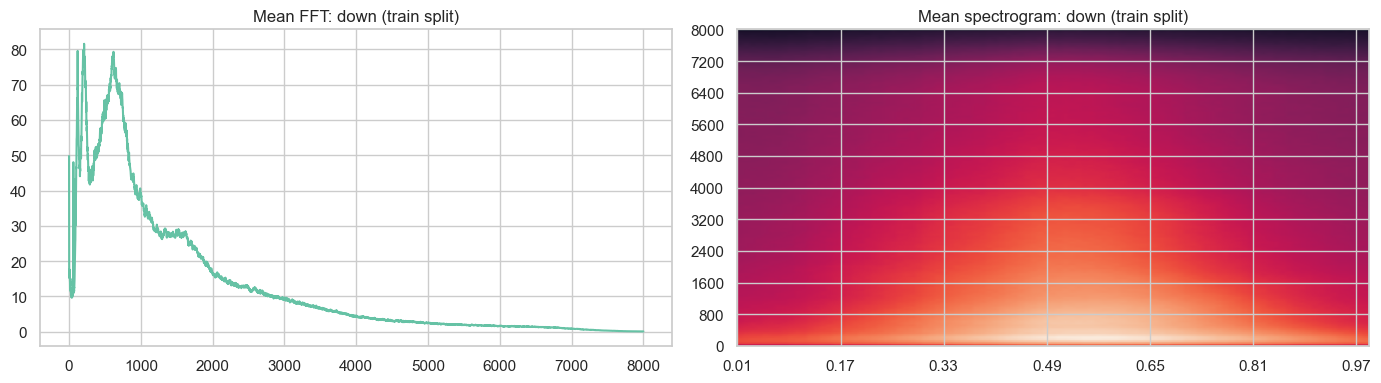

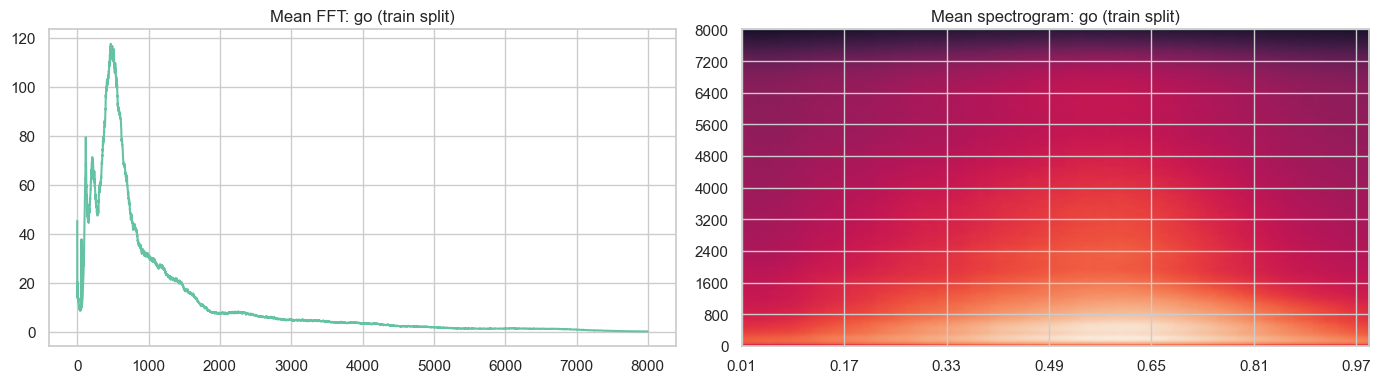

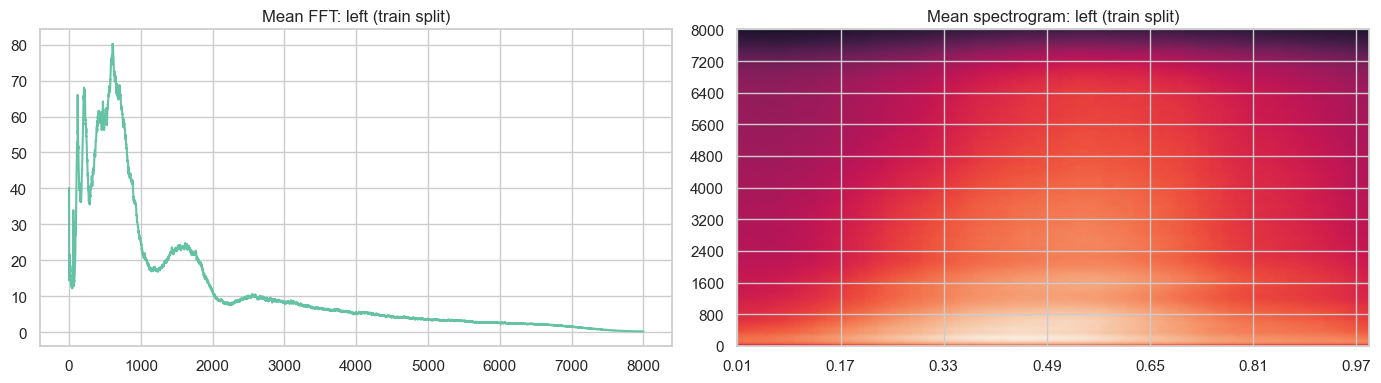

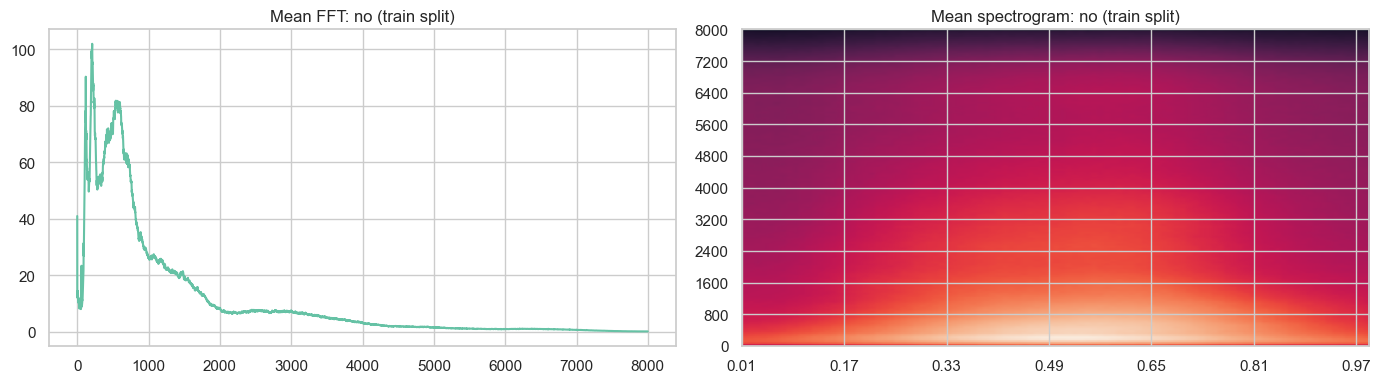

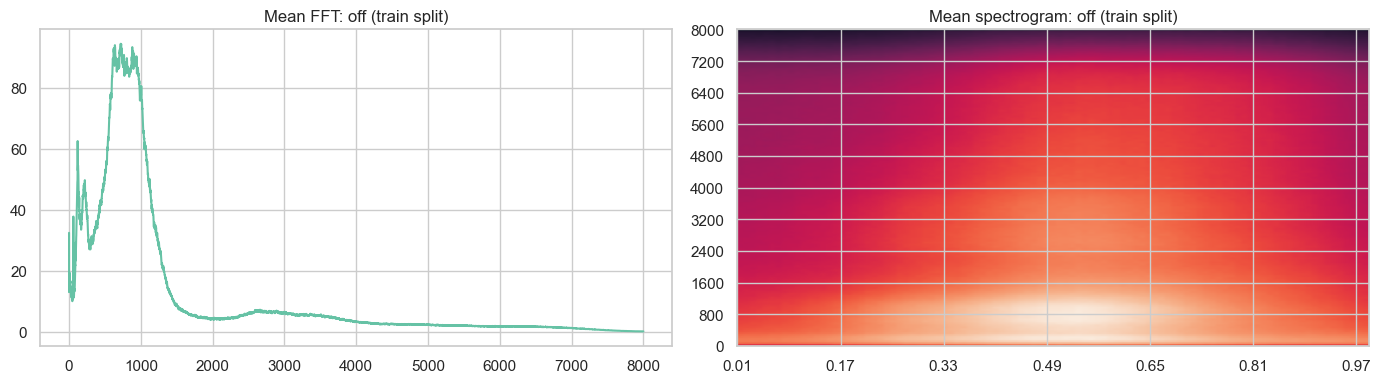

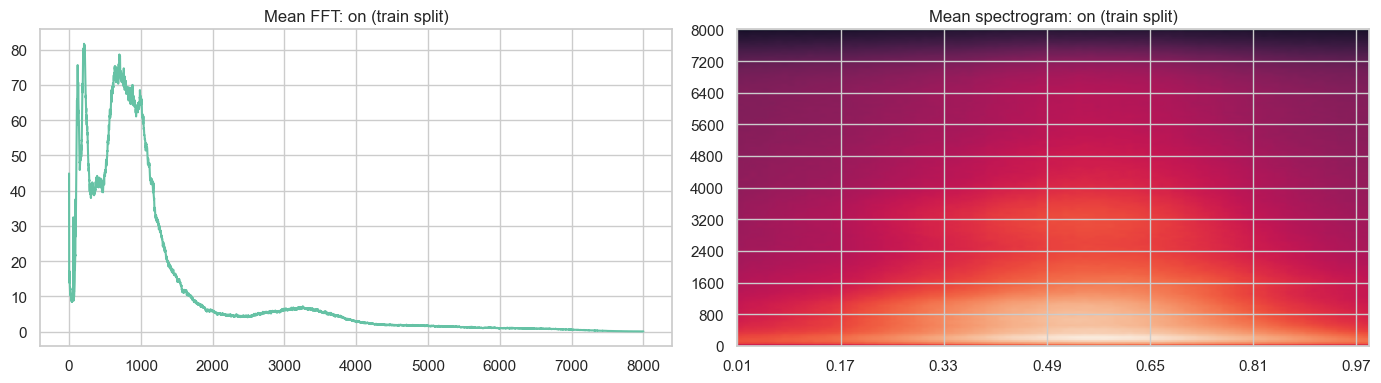

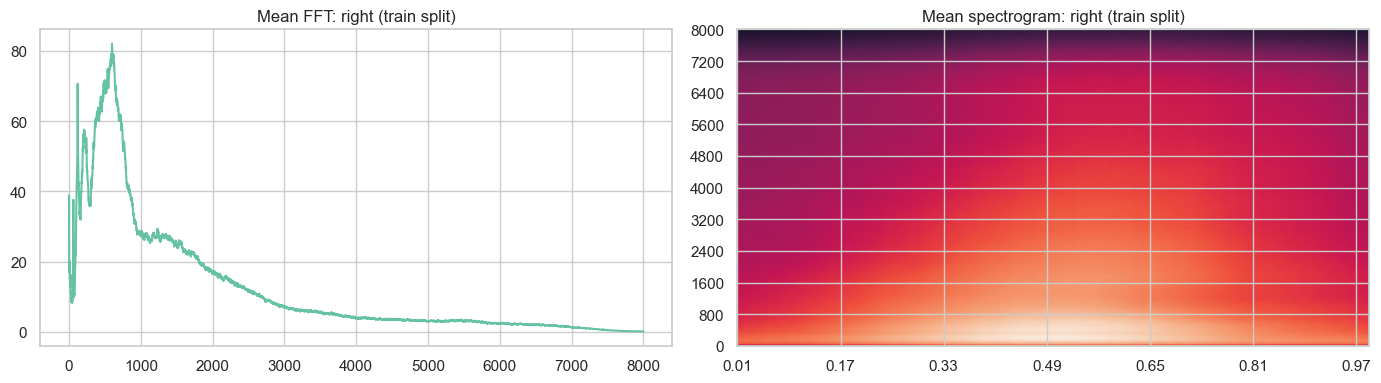

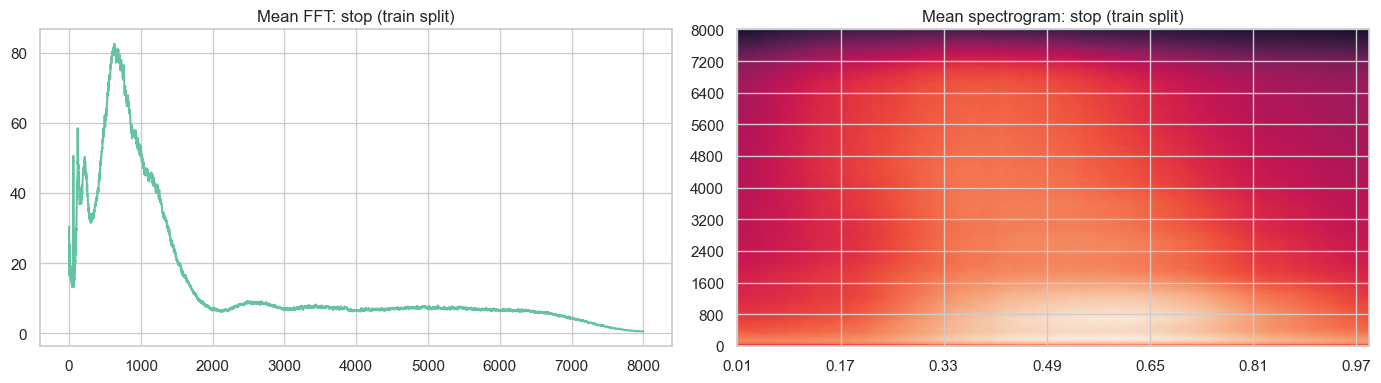

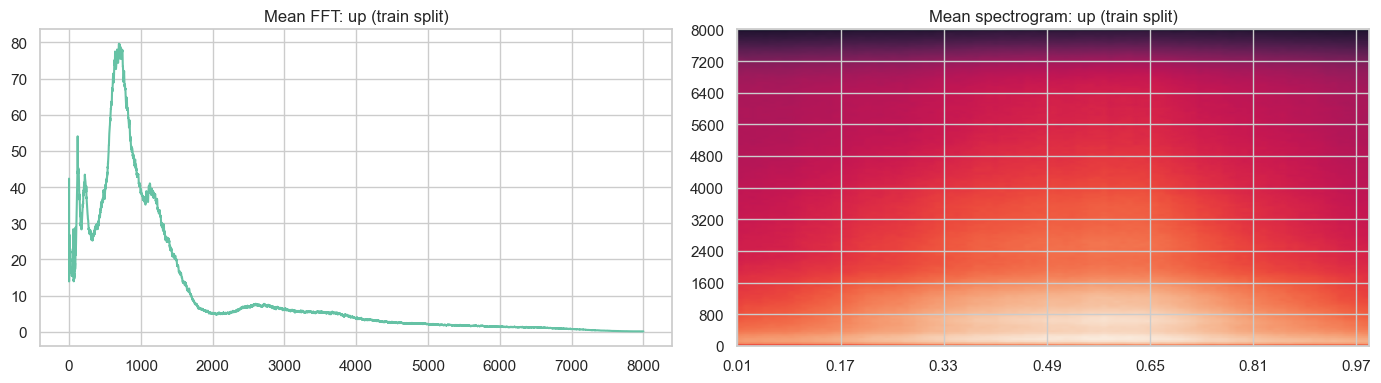

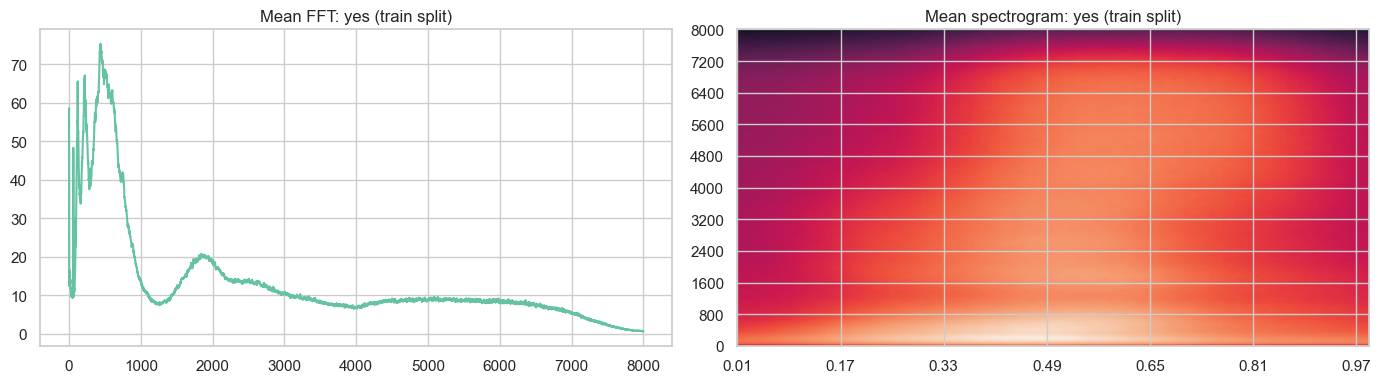

In [10]:
to_keep = ["yes", "no", "up", "down", "left", "right", "on", "off", "stop", "go"]
dirs_keep = [d for d in sorted(df_train["label"].unique()) if d in to_keep]

for direct in dirs_keep:
    vals_all = []
    spec_all = []

    rel_paths = df_train[df_train["label"] == direct]["rel_path"].tolist()
    for rel_path in rel_paths:
        sr_w, samples_w = wavfile.read(AUDIO_DIR / rel_path)
        if samples_w.shape[0] != sr_w:
            continue
        xf_w, vals_w = custom_fft(samples_w, sr_w)
        vals_all.append(vals_w)
        freqs_w, times_w, spec_w = log_specgram(samples_w, sr_w)
        spec_all.append(spec_w)

    if not vals_all or not spec_all:
        continue

    plt.figure(figsize=(14, 4))
    plt.subplot(121)
    plt.title(f"Mean FFT: {direct} (train split)")
    plt.plot(np.mean(np.array(vals_all), axis=0))
    plt.grid(True)

    plt.subplot(122)
    plt.title(f"Mean spectrogram: {direct} (train split)")
    plt.imshow(
        np.mean(np.array(spec_all), axis=0).T,
        aspect="auto",
        origin="lower",
        extent=[times_w.min(), times_w.max(), freqs_w.min(), freqs_w.max()],
    )
    plt.yticks(freqs_w[::16])
    plt.xticks(times_w[::16])
    plt.tight_layout()

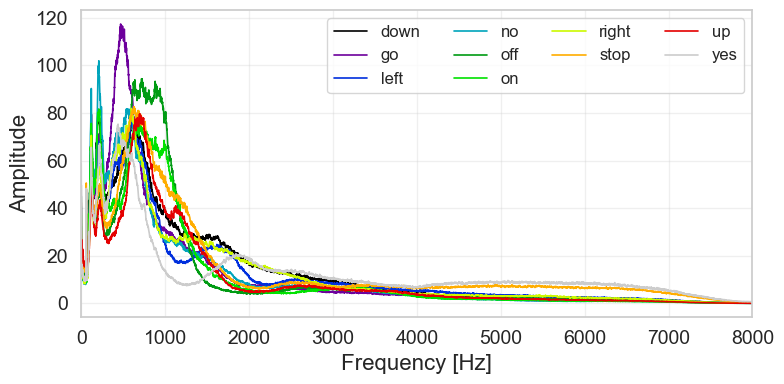

In [11]:
# Mean FFT dla wszystkich klas ze splitu train (każda klasa w innym kolorze)
all_labels = sorted(df_train["label"].unique())
mean_fft_by_label = {}
xf_ref = None

for label in all_labels:
    rel_paths = df_train.loc[df_train["label"] == label, "rel_path"].tolist()
    vals_label = []

    for rel_path in rel_paths:
        sr_tmp, samples_tmp = wavfile.read(AUDIO_DIR / rel_path)

        # zachowujemy tylko próbki o długości dokładnie 1s (jak wcześniej w notebooku)
        if samples_tmp.shape[0] != sr_tmp:
            continue

        xf_tmp, vals_tmp = custom_fft(samples_tmp, sr_tmp)
        vals_label.append(vals_tmp)
        if xf_ref is None:
            xf_ref = xf_tmp

    if vals_label:
        mean_fft_by_label[label] = np.mean(np.vstack(vals_label), axis=0)

plt.figure(figsize=(8, 4))
colors = plt.cm.nipy_spectral(np.linspace(0, 1, len(mean_fft_by_label)))

for color, (label, mean_fft) in zip(colors, mean_fft_by_label.items(), strict=False):
    plt.plot(xf_ref, mean_fft, color=color, linewidth=1.2, label=label)

# plt.title("Mean FFT per label (train split)")
plt.xlabel("Frequency [Hz]", fontsize=16)
plt.ylabel("Amplitude", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 8000)
plt.grid(True, alpha=0.3)
plt.legend(ncol=4, fontsize=12, frameon=True, loc="upper right")
plt.tight_layout()
plt.savefig("./plots/mean_fft_per_label_train.png", dpi=500)
plt.show()

## 13. Distribution of frequency components (violin plots)


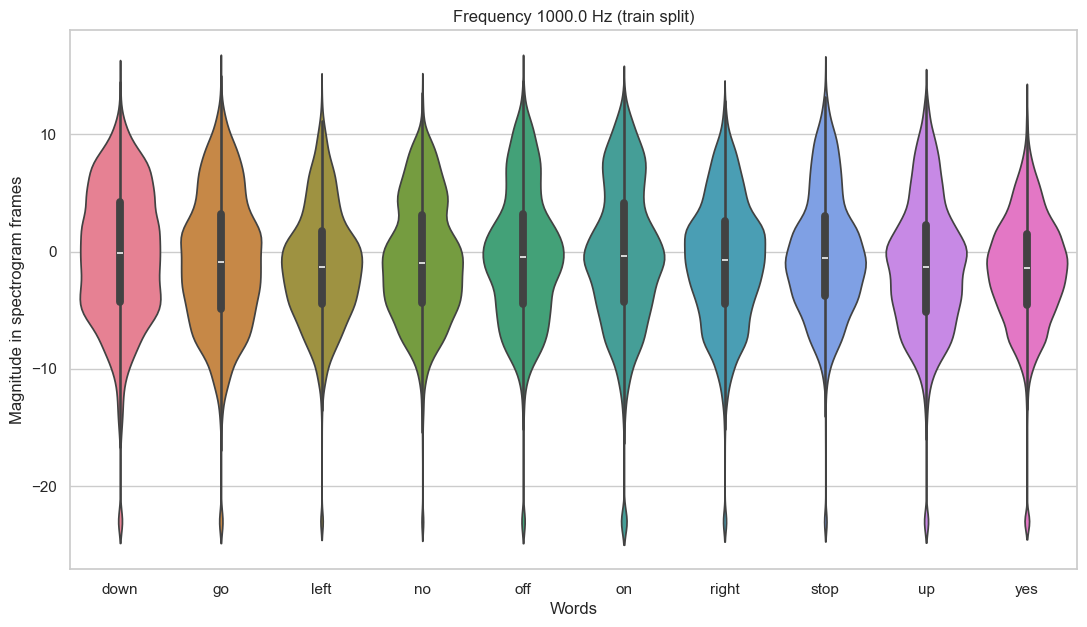

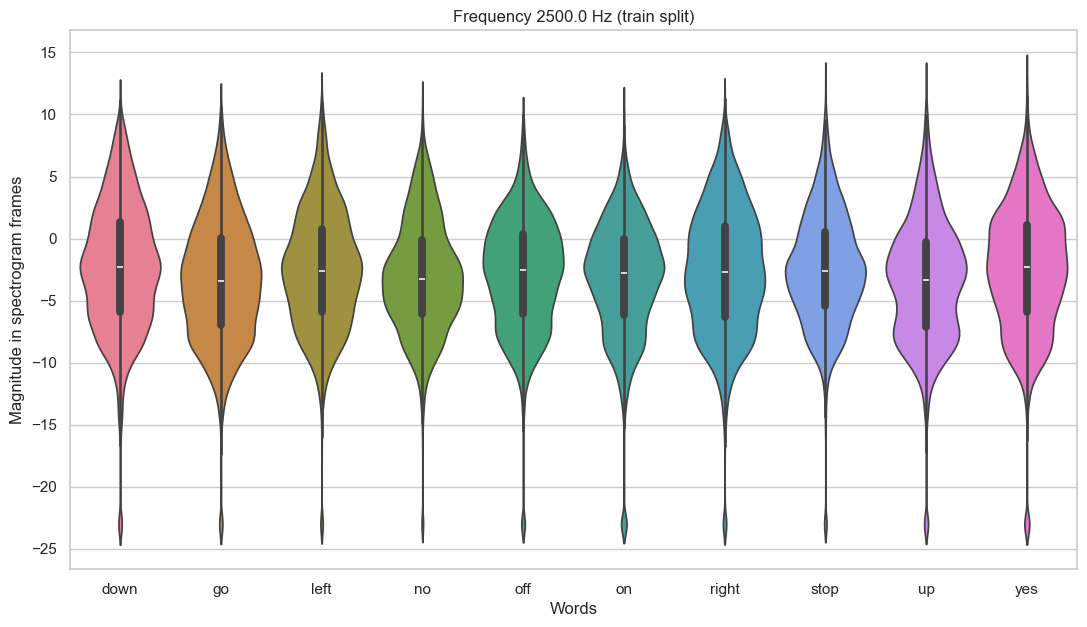

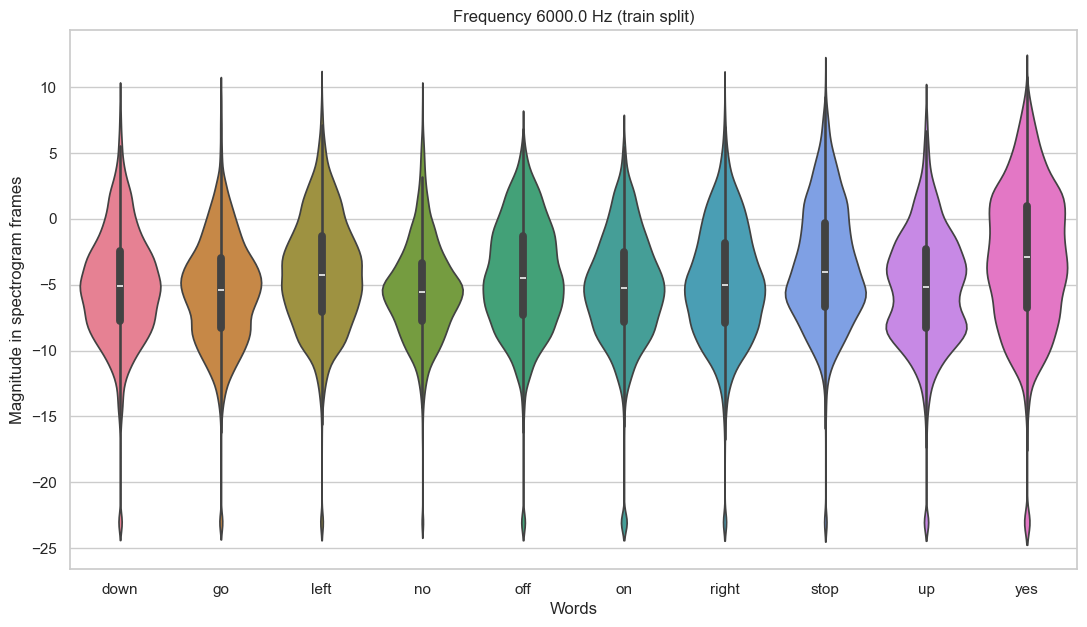

In [12]:
def violinplot_frequency(dirs_local, freq_ind):
    spec_all = []
    nonempty_labels = []
    freq_val = None

    for direct in dirs_local:
        direct_specs = []
        rel_paths = df_train[df_train["label"] == direct]["rel_path"].tolist()[:100]
        for rel_path in rel_paths:
            sr_v, samples_v = wavfile.read(AUDIO_DIR / rel_path)
            freqs_v, _, spec_v = log_specgram(samples_v, sr_v)
            if freq_ind < spec_v.shape[1]:
                direct_specs.extend(spec_v[:, freq_ind])
                freq_val = freqs_v[freq_ind]

        if direct_specs:
            spec_all.append(direct_specs)
            nonempty_labels.append(direct)

    if not spec_all:
        return

    minimum = min(len(spec) for spec in spec_all)
    spec_all = np.array([spec[:minimum] for spec in spec_all])

    plt.figure(figsize=(13, 7))
    plt.title(f"Frequency {freq_val:.1f} Hz (train split)")
    plt.ylabel("Magnitude in spectrogram frames")
    plt.xlabel("Words")
    sns.violinplot(data=pd.DataFrame(spec_all.T, columns=nonempty_labels))
    plt.show()


violinplot_frequency(dirs_keep, 20)
violinplot_frequency(dirs_keep, 50)
violinplot_frequency(dirs_keep, 120)

## 14. Unknown and background noise analysis (to fix!!!)

,group,n_files,mean_duration_s,median_duration_s,min_duration_s,max_duration_s,mean_rms
0,__unknown__,10000,0.922029,1.0,0.371563,1.0,1531.054480
1,_background_noise_,398,1.000000,1.0,1.000000,1.0,4014.987259


,group,sample_rate,count
0,__unknown__,16000,10000
1,_background_noise_,16000,398


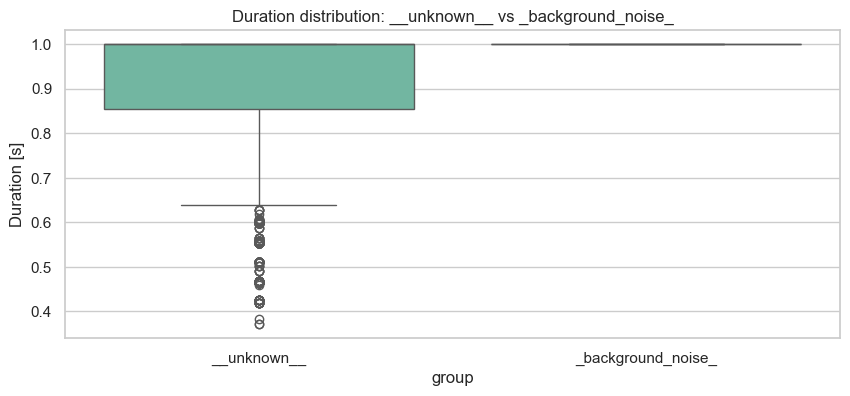

In [13]:
unknown_dir = AUDIO_DIR / "__unknown__"
background_dir = AUDIO_DIR / "_background_noise_"

unknown_files = sorted(unknown_dir.glob("*.wav"))
background_files = sorted(background_dir.glob("*.wav"))


def collect_wave_stats(paths, label):
    rows = []
    for path in paths:
        sr, sig = wavfile.read(path)
        duration = len(sig) / sr
        rows.append(
            {
                "group": label,
                "file": path.name,
                "sample_rate": sr,
                "n_samples": len(sig),
                "duration_s": duration,
                "rms": float(np.sqrt(np.mean(sig.astype(np.float64) ** 2))),
            }
        )
    return pd.DataFrame(rows)


unknown_stats = collect_wave_stats(unknown_files, "__unknown__")
background_stats = collect_wave_stats(background_files, "_background_noise_")

stats_df = pd.concat([unknown_stats, background_stats], ignore_index=True)
summary_df = (
    stats_df.groupby("group")
    .agg(
        n_files=("file", "count"),
        mean_duration_s=("duration_s", "mean"),
        median_duration_s=("duration_s", "median"),
        min_duration_s=("duration_s", "min"),
        max_duration_s=("duration_s", "max"),
        mean_rms=("rms", "mean"),
    )
    .reset_index()
)

display(summary_df)

display(stats_df.groupby("group")["sample_rate"].value_counts().rename("count").reset_index())

plt.figure(figsize=(10, 4))
sns.boxplot(data=stats_df, x="group", y="duration_s")
plt.title("Duration distribution: __unknown__ vs _background_noise_")
plt.ylabel("Duration [s]")
plt.show()

Unknown FFT vectors: 1201
Background FFT vectors (1s chunks): 398


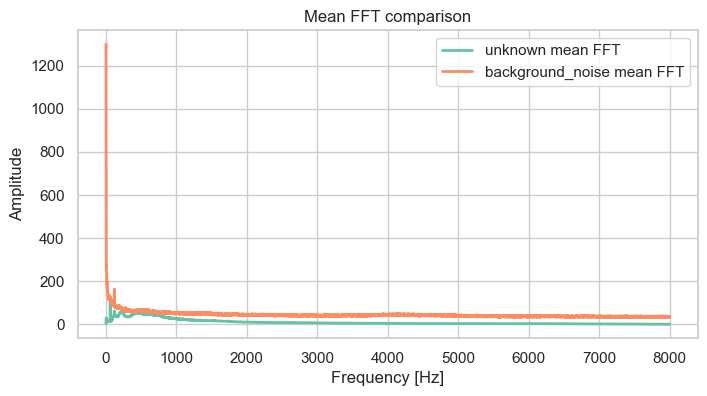

In [14]:
def collect_unknown_fft(paths, max_items=1200):
    fft_values = []
    fft_freq = None
    for i, path in enumerate(paths):
        sr, sig = wavfile.read(path)
        if len(sig) < sr:
            sig = np.pad(sig, (0, sr - len(sig)))
        elif len(sig) > sr:
            sig = sig[:sr]
        xf, vals = custom_fft(sig, sr)
        fft_values.append(vals)
        fft_freq = xf
        if i >= max_items:
            break
    return np.array(fft_values), fft_freq


def collect_background_chunks_fft(paths, max_chunks=1200, chunk_seconds=1):
    fft_values = []
    fft_freq = None
    chunk_count = 0
    for path in paths:
        sr, sig = wavfile.read(path)
        chunk_len = int(sr * chunk_seconds)
        if chunk_len <= 0:
            continue
        n_chunks = len(sig) // chunk_len
        for i in range(n_chunks):
            chunk = sig[i * chunk_len : (i + 1) * chunk_len]
            if len(chunk) != chunk_len:
                continue
            xf, vals = custom_fft(chunk, sr)
            fft_values.append(vals)
            fft_freq = xf
            chunk_count += 1
            if chunk_count >= max_chunks:
                return np.array(fft_values), fft_freq
    return np.array(fft_values), fft_freq


unknown_fft, unknown_xf = collect_unknown_fft(unknown_files)
bg_fft, bg_xf = collect_background_chunks_fft(background_files)

print(f"Unknown FFT vectors: {unknown_fft.shape[0]}")
print(f"Background FFT vectors (1s chunks): {bg_fft.shape[0]}")

plt.figure(figsize=(8, 4))
if unknown_fft.size > 0:
    plt.plot(unknown_xf, unknown_fft.mean(axis=0), label="unknown mean FFT", linewidth=2)
if bg_fft.size > 0:
    plt.plot(bg_xf, bg_fft.mean(axis=0), label="background_noise mean FFT", linewidth=2)
plt.title("Mean FFT comparison")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend()
# plt.savefig("./plots/unknown_vs_background_fft.png", dpi=500)
plt.show()

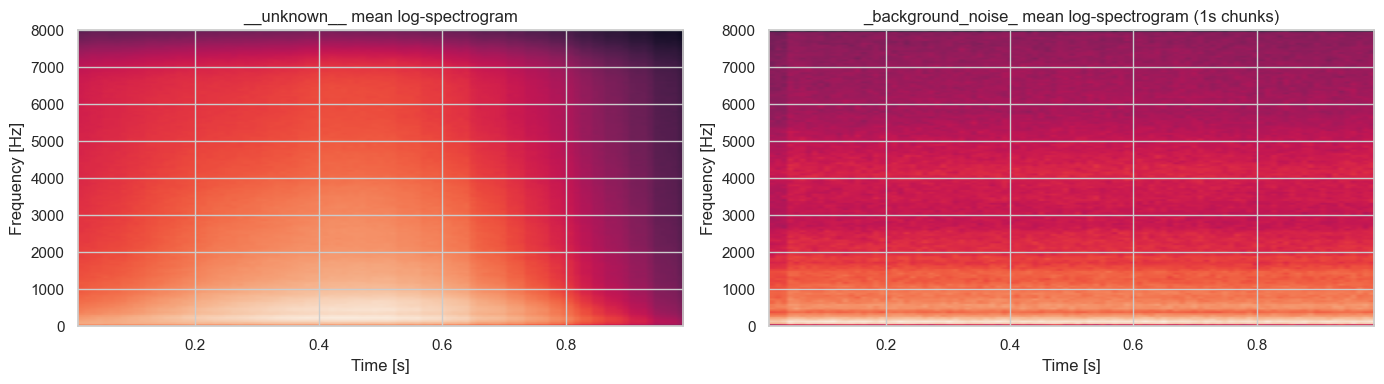

In [15]:
def collect_unknown_spec(paths, max_items=700):
    specs = []
    freqs_ref = None
    times_ref = None
    for idx, path in enumerate(paths):
        sr, sig = wavfile.read(path)
        if len(sig) < sr:
            sig = np.pad(sig, (0, sr - len(sig)))
        elif len(sig) > sr:
            sig = sig[:sr]
        freqs, times, spec = log_specgram(sig, sr)
        specs.append(spec)
        freqs_ref = freqs
        times_ref = times
        if idx >= max_items - 1:
            break
    return np.array(specs), freqs_ref, times_ref


def collect_background_chunks_spec(paths, max_chunks=700, chunk_seconds=1):
    specs = []
    freqs_ref = None
    times_ref = None
    chunk_count = 0
    for path in paths:
        sr, sig = wavfile.read(path)
        chunk_len = int(sr * chunk_seconds)
        if chunk_len <= 0:
            continue
        n_chunks = len(sig) // chunk_len
        for i in range(n_chunks):
            chunk = sig[i * chunk_len : (i + 1) * chunk_len]
            if len(chunk) != chunk_len:
                continue
            freqs, times, spec = log_specgram(chunk, sr)
            specs.append(spec)
            freqs_ref = freqs
            times_ref = times
            chunk_count += 1
            if chunk_count >= max_chunks:
                return np.array(specs), freqs_ref, times_ref
    return np.array(specs), freqs_ref, times_ref


unknown_spec, uf, ut = collect_unknown_spec(unknown_files)
bg_spec, bf, bt = collect_background_chunks_spec(background_files)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

if unknown_spec.size > 0:
    axes[0].imshow(
        unknown_spec.mean(axis=0).T,
        aspect="auto",
        origin="lower",
        extent=[ut.min(), ut.max(), uf.min(), uf.max()],
    )
axes[0].set_title("__unknown__ mean log-spectrogram")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Frequency [Hz]")

if bg_spec.size > 0:
    axes[1].imshow(
        bg_spec.mean(axis=0).T,
        aspect="auto",
        origin="lower",
        extent=[bt.min(), bt.max(), bf.min(), bf.max()],
    )
axes[1].set_title("_background_noise_ mean log-spectrogram (1s chunks)")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Frequency [Hz]")

plt.tight_layout()
plt.show()

rms                    zcr          
                           mean          std      mean       std
group                                                           
__unknown__         1461.023711  1080.317477  0.108577  0.051270
_background_noise_  4014.987259  4583.208641  0.328398  0.143894

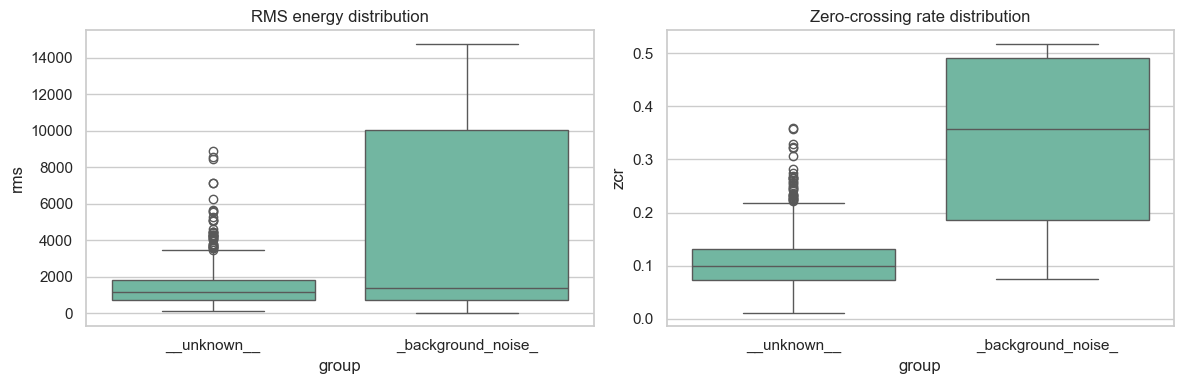

In [16]:
unknown_sample = []
for path in unknown_files[:800]:
    sr, sig = wavfile.read(path)
    if len(sig) < sr:
        sig = np.pad(sig, (0, sr - len(sig)))
    elif len(sig) > sr:
        sig = sig[:sr]
    unknown_sample.append(sig.astype(np.float64))

bg_sample = []
for path in background_files:
    sr, sig = wavfile.read(path)
    chunk_len = sr
    n_chunks = len(sig) // chunk_len
    for i in range(min(n_chunks, 100)):
        chunk = sig[i * chunk_len : (i + 1) * chunk_len].astype(np.float64)
        bg_sample.append(chunk)
        if len(bg_sample) >= 800:
            break
    if len(bg_sample) >= 800:
        break


def feature_frame(waves, label):
    rows = []
    for w in waves:
        rows.append(
            {
                "group": label,
                "rms": float(np.sqrt(np.mean(w**2))),
                "zcr": float(np.mean(np.abs(np.diff(np.sign(w))) > 0)),
            }
        )
    return pd.DataFrame(rows)


feat_df = pd.concat(
    [
        feature_frame(unknown_sample, "__unknown__"),
        feature_frame(bg_sample, "_background_noise_"),
    ],
    ignore_index=True,
)
display(feat_df.groupby("group").agg({"rms": ["mean", "std"], "zcr": ["mean", "std"]}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=feat_df, x="group", y="rms", ax=axes[0])
axes[0].set_title("RMS energy distribution")

sns.boxplot(data=feat_df, x="group", y="zcr", ax=axes[1])
axes[1].set_title("Zero-crossing rate distribution")

plt.tight_layout()
plt.show()

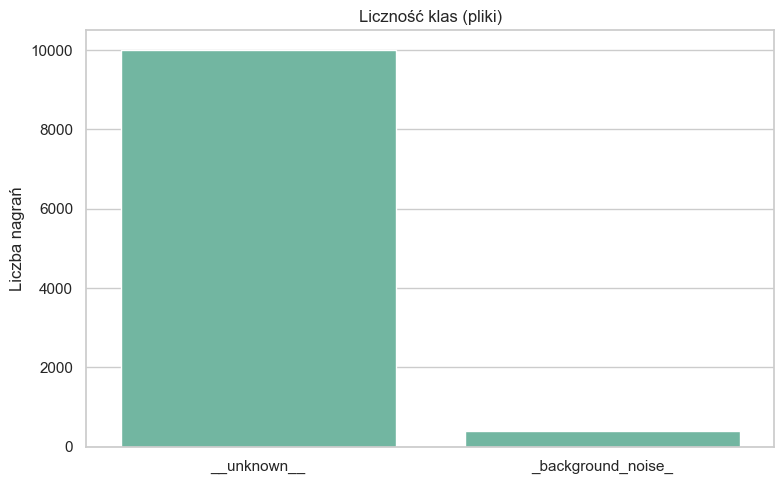

In [17]:
class_counts_files = pd.DataFrame(
    {
        "group": ["__unknown__", "_background_noise_"],
        "count": [len(unknown_files), len(background_files)],
    }
)

plt.figure(figsize=(8, 5))
sns.barplot(data=class_counts_files, x="group", y="count")
plt.title("Liczność klas (pliki)")
plt.xlabel("")
plt.ylabel("Liczba nagrań")

plt.tight_layout()
plt.show()

split,label,test,train,validation,total
0,unknown,2368,18946,2368,23682
1,stop,245,1878,257,2380
2,yes,215,1904,258,2377
3,no,250,1908,217,2375
4,up,231,1908,236,2375
5,go,242,1899,231,2372
6,on,255,1891,221,2367
7,right,231,1907,229,2367
8,down,261,1867,231,2359
9,off,228,1890,239,2357


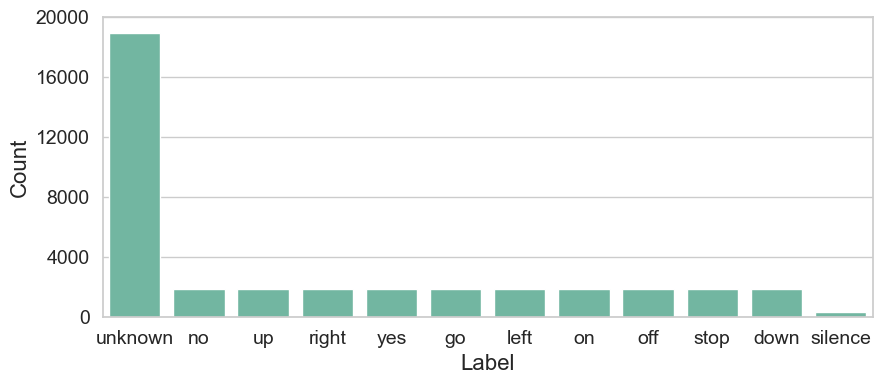

In [23]:
# Wczytanie list extended_* ze split_lists
ext_train_list = read_split_list("extended_training_list.txt")
ext_val_list = read_split_list("extended_validation_list.txt")
ext_test_list = read_split_list("extended_testing_list.txt")

# DataFrame dla extended splitów
df_ext_train = make_split_df("train", ext_train_list)
df_ext_val = make_split_df("validation", ext_val_list)
df_ext_test = make_split_df("test", ext_test_list)
df_ext_all = pd.concat([df_ext_train, df_ext_val, df_ext_test], ignore_index=True)
keep_labels = {
    "yes",
    "no",
    "up",
    "down",
    "left",
    "right",
    "on",
    "off",
    "stop",
    "go",
    "_background_noise_",
}
df_ext_all["label"] = df_ext_all["label"].where(df_ext_all["label"].isin(keep_labels), "unknown")
df_ext_all["label"] = df_ext_all["label"].replace({"_background_noise_": "silence"})

# Liczność klas per split
ext_counts = df_ext_all.groupby(["label", "split"]).size().reset_index(name="count")


ext_counts_pivot = (
    ext_counts.pivot(index="label", columns="split", values="count").fillna(0).astype(int)
)
# Sortowanie po łącznej liczbie przykładów
ext_counts_pivot["total"] = ext_counts_pivot.sum(axis=1)
ext_counts_pivot = ext_counts_pivot.sort_values("total", ascending=False)

display(ext_counts_pivot.reset_index())

# Histogram klas (z podziałem na train/validation/test)
plt.figure(figsize=(9, 4))
sns.barplot(
    data=ext_counts[ext_counts["split"] == "train"],
    x="label",
    y="count",
    order=ext_counts_pivot.sort_values("train", ascending=False).index,
)
# plt.title("Histogram klas dla extended split lists")
plt.xlabel("Label", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.xticks(rotation=0, fontsize=14)
plt.yticks(ticks=np.arange(0, 20001, 4000), fontsize=14)
plt.tight_layout()
plt.savefig("./plots/extended_split_class_histogram.png", dpi=500)
plt.show()